PART A — Dataset Preparation and Text Preprocessing

In [ ]:
print("Akhilon S - 24BAD008")
import numpy as np
import pandas as pd
import tensorflow as tf
import re
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Set parameters
vocab_size = 10000
max_length = 200

# Load IMDB dataset
(X_train, y_train), (X_test, y_test) = imdb.load_data(
    num_words=vocab_size
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("First training sequence:")
print(X_train[0])

print("First training label:")
print(y_train[0])

print("Positive reviews:", np.sum(y_train == 1))
print("Negative reviews:", np.sum(y_train == 0))

# Padding sequences
X_train = pad_sequences(
    X_train,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

X_test = pad_sequences(
    X_test,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

print("Training labels shape:", y_train.shape)
print("Testing labels shape:", y_test.shape)

Akhilon S - 24BAD008
Training samples: 25000
Testing samples: 25000
First training sequence:
[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103

PART B — Embedding Generation

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding

embedding_dim = 128

embedding_model = Sequential([
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        input_length=max_length
    )
])

embedding_model.build(input_shape=(None, max_length))

embedding_model.summary()

embedding_output = embedding_model(X_train[:1])

print("Input shape:", X_train[:1].shape)
print("Embedding output shape:", embedding_output.shape)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 200, 128)       │     1,280,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,280,000 (4.88 MB)

 Trainable params: 1,280,000 (4.88 MB)

 Non-trainable params: 0 (0.00 B)

Input shape: (1, 200)
Embedding output shape: (1, 200, 128)


PART C: IMPLEMENTING THE LSTM MODEL

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

model = Sequential([
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        input_length=max_length
    ),

    LSTM(128),

    Dropout(0.5),

    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.build(input_shape=(None, max_length))

model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,411,713 (5.39 MB)

 Trainable params: 1,411,713 (5.39 MB)

 Non-trainable params: 0 (0.00 B)

PART D — Model Training and Sentiment Prediction

Step 1 — Create validation data

In [ ]:
X_val = X_train[-5000:]
y_val = y_train[-5000:]

X_train_new = X_train[:-5000]
y_train_new = y_train[:-5000]

print("Training data:", X_train_new.shape)
print("Validation data:", X_val.shape)
print("Testing data:", X_test.shape)

Training data: (20000, 200)
Validation data: (5000, 200)
Testing data: (25000, 200)


Step 2 — Train the LSTM

In [ ]:
history = model.fit(
    X_train_new,
    y_train_new,
    epochs=5,
    batch_size=64,
    validation_data=(X_val, y_val)
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 167s 525ms/step - accuracy: 0.5186 - loss: 0.6968 - val_accuracy: 0.5114 - val_loss: 0.6919
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 147s 468ms/step - accuracy: 0.5615 - loss: 0.6727 - val_accuracy: 0.5496 - val_loss: 0.6804
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 145s 463ms/step - accuracy: 0.6141 - loss: 0.6241 - val_accuracy: 0.5966 - val_loss: 0.6500
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 143s 458ms/step - accuracy: 0.7689 - loss: 0.4917 - val_accuracy: 0.7574 - val_loss: 0.6243
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 152s 486ms/step - accuracy: 0.8863 - loss: 0.3047 - val_accuracy: 0.8446 - val_loss: 0.4011


Step 3 — Plot Accuracy vs Epoch

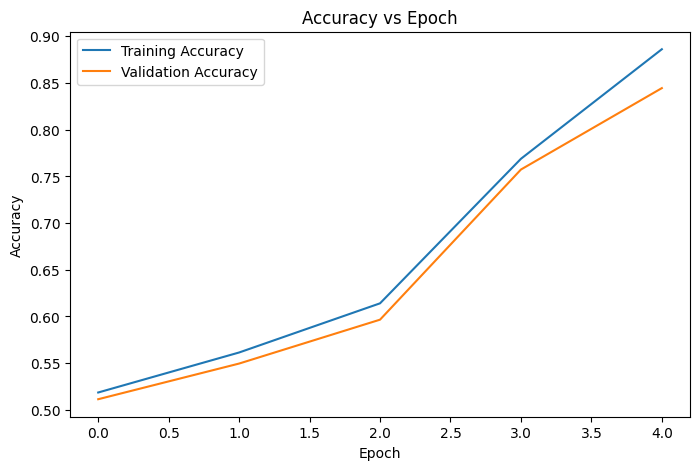

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title('Accuracy vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

Step 4 — Plot Loss vs Epoch

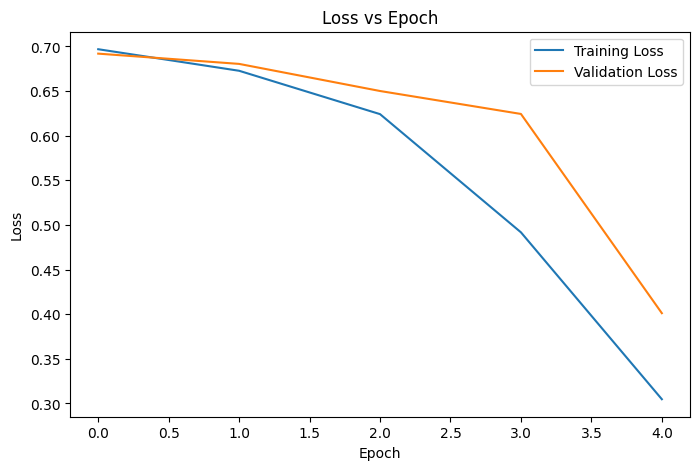

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.title('Loss vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

Step 5 — Evaluate the Test Dataset

In [ ]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

782/782 ━━━━━━━━━━━━━━━━━━━━ 71s 91ms/step - accuracy: 0.8278 - loss: 0.4195
Test Loss: 0.4195275902748108
Test Accuracy: 0.8277999758720398


Step 6 — Generate Predictions

In [ ]:
y_probability = model.predict(X_test)

y_pred = (y_probability >= 0.5).astype(int)

print("Predicted labels:")
print(y_pred[:20].flatten())

print("Actual labels:")
print(y_test[:20])

782/782 ━━━━━━━━━━━━━━━━━━━━ 80s 102ms/step
Predicted labels:
[0 1 0 1 1 1 0 0 1 1 1 0 0 1 1 0 1 1 0 0]
Actual labels:
[0 1 1 0 1 1 1 0 0 1 1 0 0 0 1 0 1 0 0 0]


Step 7 — Accuracy, Precision, Recall and F1-Score

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-Score :", f1)

Accuracy : 0.8278
Precision: 0.7997658936279172
Recall   : 0.87456
F1-Score : 0.8354923764759831


Step 8 — Confusion Matrix

Confusion Matrix:
[[ 9763  2737]
 [ 1568 10932]]


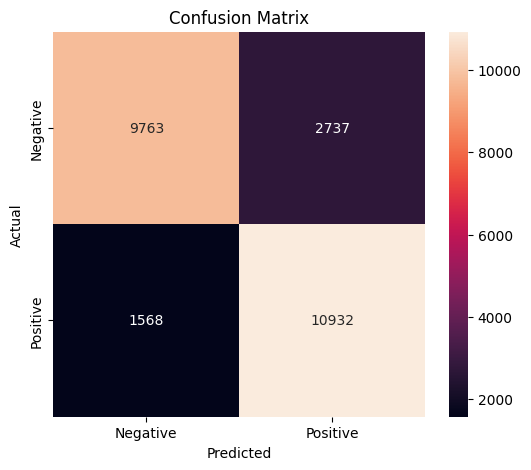

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['Negative', 'Positive'],
    yticklabels=['Negative', 'Positive']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.show()

Step 9 — Predict Sample Reviews

In [ ]:
word_index = imdb.get_word_index()

def encode_review(text):
    words = text.lower().split()

    sequence = []

    for word in words:
        word = re.sub(r'[^a-zA-Z]', '', word)

        if word in word_index and word_index[word] < vocab_size - 3:
            sequence.append(word_index[word] + 3)
        else:
            sequence.append(2)

    return pad_sequences(
        [sequence],
        maxlen=max_length,
        padding='post',
        truncating='post'
    )

sample_reviews = [
    "This movie was excellent and I really enjoyed it",
    "The movie was boring and disappointing"
]

for review in sample_reviews:

    encoded_review = encode_review(review)

    probability = model.predict(encoded_review)[0][0]

    if probability >= 0.5:
        sentiment = "Positive"
    else:
        sentiment = "Negative"

    print("Review:", review)
    print("Probability:", probability)
    print("Predicted Sentiment:", sentiment)
    print()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
Review: This movie was excellent and I really enjoyed it
Probability: 0.96561116
Predicted Sentiment: Positive

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
Review: The movie was boring and disappointing
Probability: 0.0947344
Predicted Sentiment: Negative

